In [25]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import joblib
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

np.random.seed(42)

def generate_healthy_session(duration=60, fs=100):
    n = duration * fs
    t = np.linspace(0, duration, n)
    noise_level = np.random.uniform(0.02, 0.04) 
    x = np.random.normal(0, noise_level, n)
    y = 9.81 + np.random.normal(0, noise_level, n)
    z = np.random.normal(0, noise_level, n)
    
    # ADD OVERLAP: Some healthy people have 8-12Hz shakes
    if np.random.random() < 0.2:
        shake_freq = np.random.uniform(8.0, 12.0)
        shake_amp = np.random.uniform(0.02, 0.05)
        x += shake_amp * np.sin(2 * np.pi * shake_freq * t)
    return x, y, z

def generate_parkinsons_session(duration=60, fs=100):
    n = duration * fs
    t = np.linspace(0, duration, n)
    tremor_freq = np.random.uniform(3.8, 6.2)
    tremor_amp = np.random.uniform(0.015, 0.35) # Lower limit creates the challenge
    
    mask = np.ones(n)
    if np.random.random() > 0.4: # Tremor breaks for 2 seconds
        start_break = np.random.randint(0, n-200)
        mask[start_break : start_break+200] = 0
    
    mod = (1 + 0.5 * np.sin(2 * np.pi * 0.1 * t)) * mask
    x = (tremor_amp * mod * np.sin(2*np.pi*tremor_freq*t) + np.random.normal(0, 0.03, n))
    y = 9.81 + (tremor_amp * 0.7 * mod * np.sin(2*np.pi*tremor_freq*t) + np.random.normal(0, 0.03, n))
    z = (tremor_amp * 0.5 * mod * np.sin(2*np.pi*tremor_freq*t) + np.random.normal(0, 0.03, n))
    return x, y, z


In [26]:
print("🔨 Building Realistic Dataset...")
all_rows = []
for i in range(200):
    x, y, z = generate_parkinsons_session()
    for vx, vy, vz in zip(x, y, z):
        all_rows.append({'session_id': f'PD_{i}', 'x': vx, 'y': vy, 'z': vz, 'label': 1})

for i in range(200):
    x, y, z = generate_healthy_session()
    for vx, vy, vz in zip(x, y, z):
        all_rows.append({'session_id': f'HC_{i}', 'x': vx, 'y': vy, 'z': vz, 'label': 0})

csv_path = r'../data/synthetic tremor/synthetic_tremor_data.csv'
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
pd.DataFrame(all_rows).to_csv(csv_path, index=False)
print(f"💾 Dataset saved to: {csv_path}")


🔨 Building Realistic Dataset...
💾 Dataset saved to: ../data/synthetic tremor/synthetic_tremor_data.csv


In [28]:
def extract_tremor_features(x, y, z, fs=100):
    if len(x) < 256: return None
    
    # NEW: Compatibility Fix for NumPy 2.0+
    integrate = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
    
    mag = np.sqrt(x**2 + y**2 + z**2)
    # Filter
    b, a = butter(4, 0.5/(fs/2), btype='high')
    clean = filtfilt(b, a, mag)
    b2, a2 = butter(4, [3.0/(fs/2), 8.0/(fs/2)], btype='band')
    tremor = filtfilt(b2, a2, clean)
    
    # Power Spectral Density
    f, p = welch(tremor, fs=fs, nperseg=256)
    p += 1e-10
    total_p = integrate(p, f) # Use the compatible integrate function
    
    tm = (f >= 3) & (f <= 8)
    dom_f = f[tm][np.argmax(p[tm])] if any(tm) else 0
    t_p = integrate(p[tm], f[tm]) if any(tm) else 0 # Use the compatible integrate function
    
    entropy = -np.sum((p/total_p) * np.log(p/total_p + 1e-10))
    
    return [dom_f, t_p, t_p/total_p, np.std(tremor), np.max(np.abs(tremor)), 
            np.mean(np.abs(tremor)), np.sqrt(np.mean(tremor**2)), float(skew(tremor)), 
            float(kurtosis(tremor)), np.sum(np.diff(np.sign(tremor))!=0)/len(tremor), 
            integrate(p[f<3], f[f<3]), integrate(p[f>8], f[f>8]), entropy]

print("📖 Extracting features from windows (Compatibility Fix applied)...")
df_raw = pd.read_csv(csv_path)
all_feat, all_lab = [], []
feature_names = ['dom_freq', 'tremor_pwr', 'tremor_ratio', 'std', 'max_amp', 'mean_amp', 'rms', 'skew', 'kurtosis', 'zcr', 'low_pwr', 'high_pwr', 'entropy']

for sid, group in df_raw.groupby('session_id'):
    x, y, z, lab = group['x'].values, group['y'].values, group['z'].values, group['label'].iloc[0]
    for s in range(0, len(x)-500, 250):
        feat = extract_tremor_features(x[s:s+500], y[s:s+500], z[s:s+500])
        if feat: all_feat.append(feat); all_lab.append(lab)

X, y = np.array(all_feat), np.array(all_lab)
print(f"✅ Ready: {len(X)} samples created.")


📖 Extracting features from windows (Compatibility Fix applied)...
✅ Ready: 8800 samples created.


✅ Visualization saved to: ../models/tremor_model\tremor_feature_comparison.png


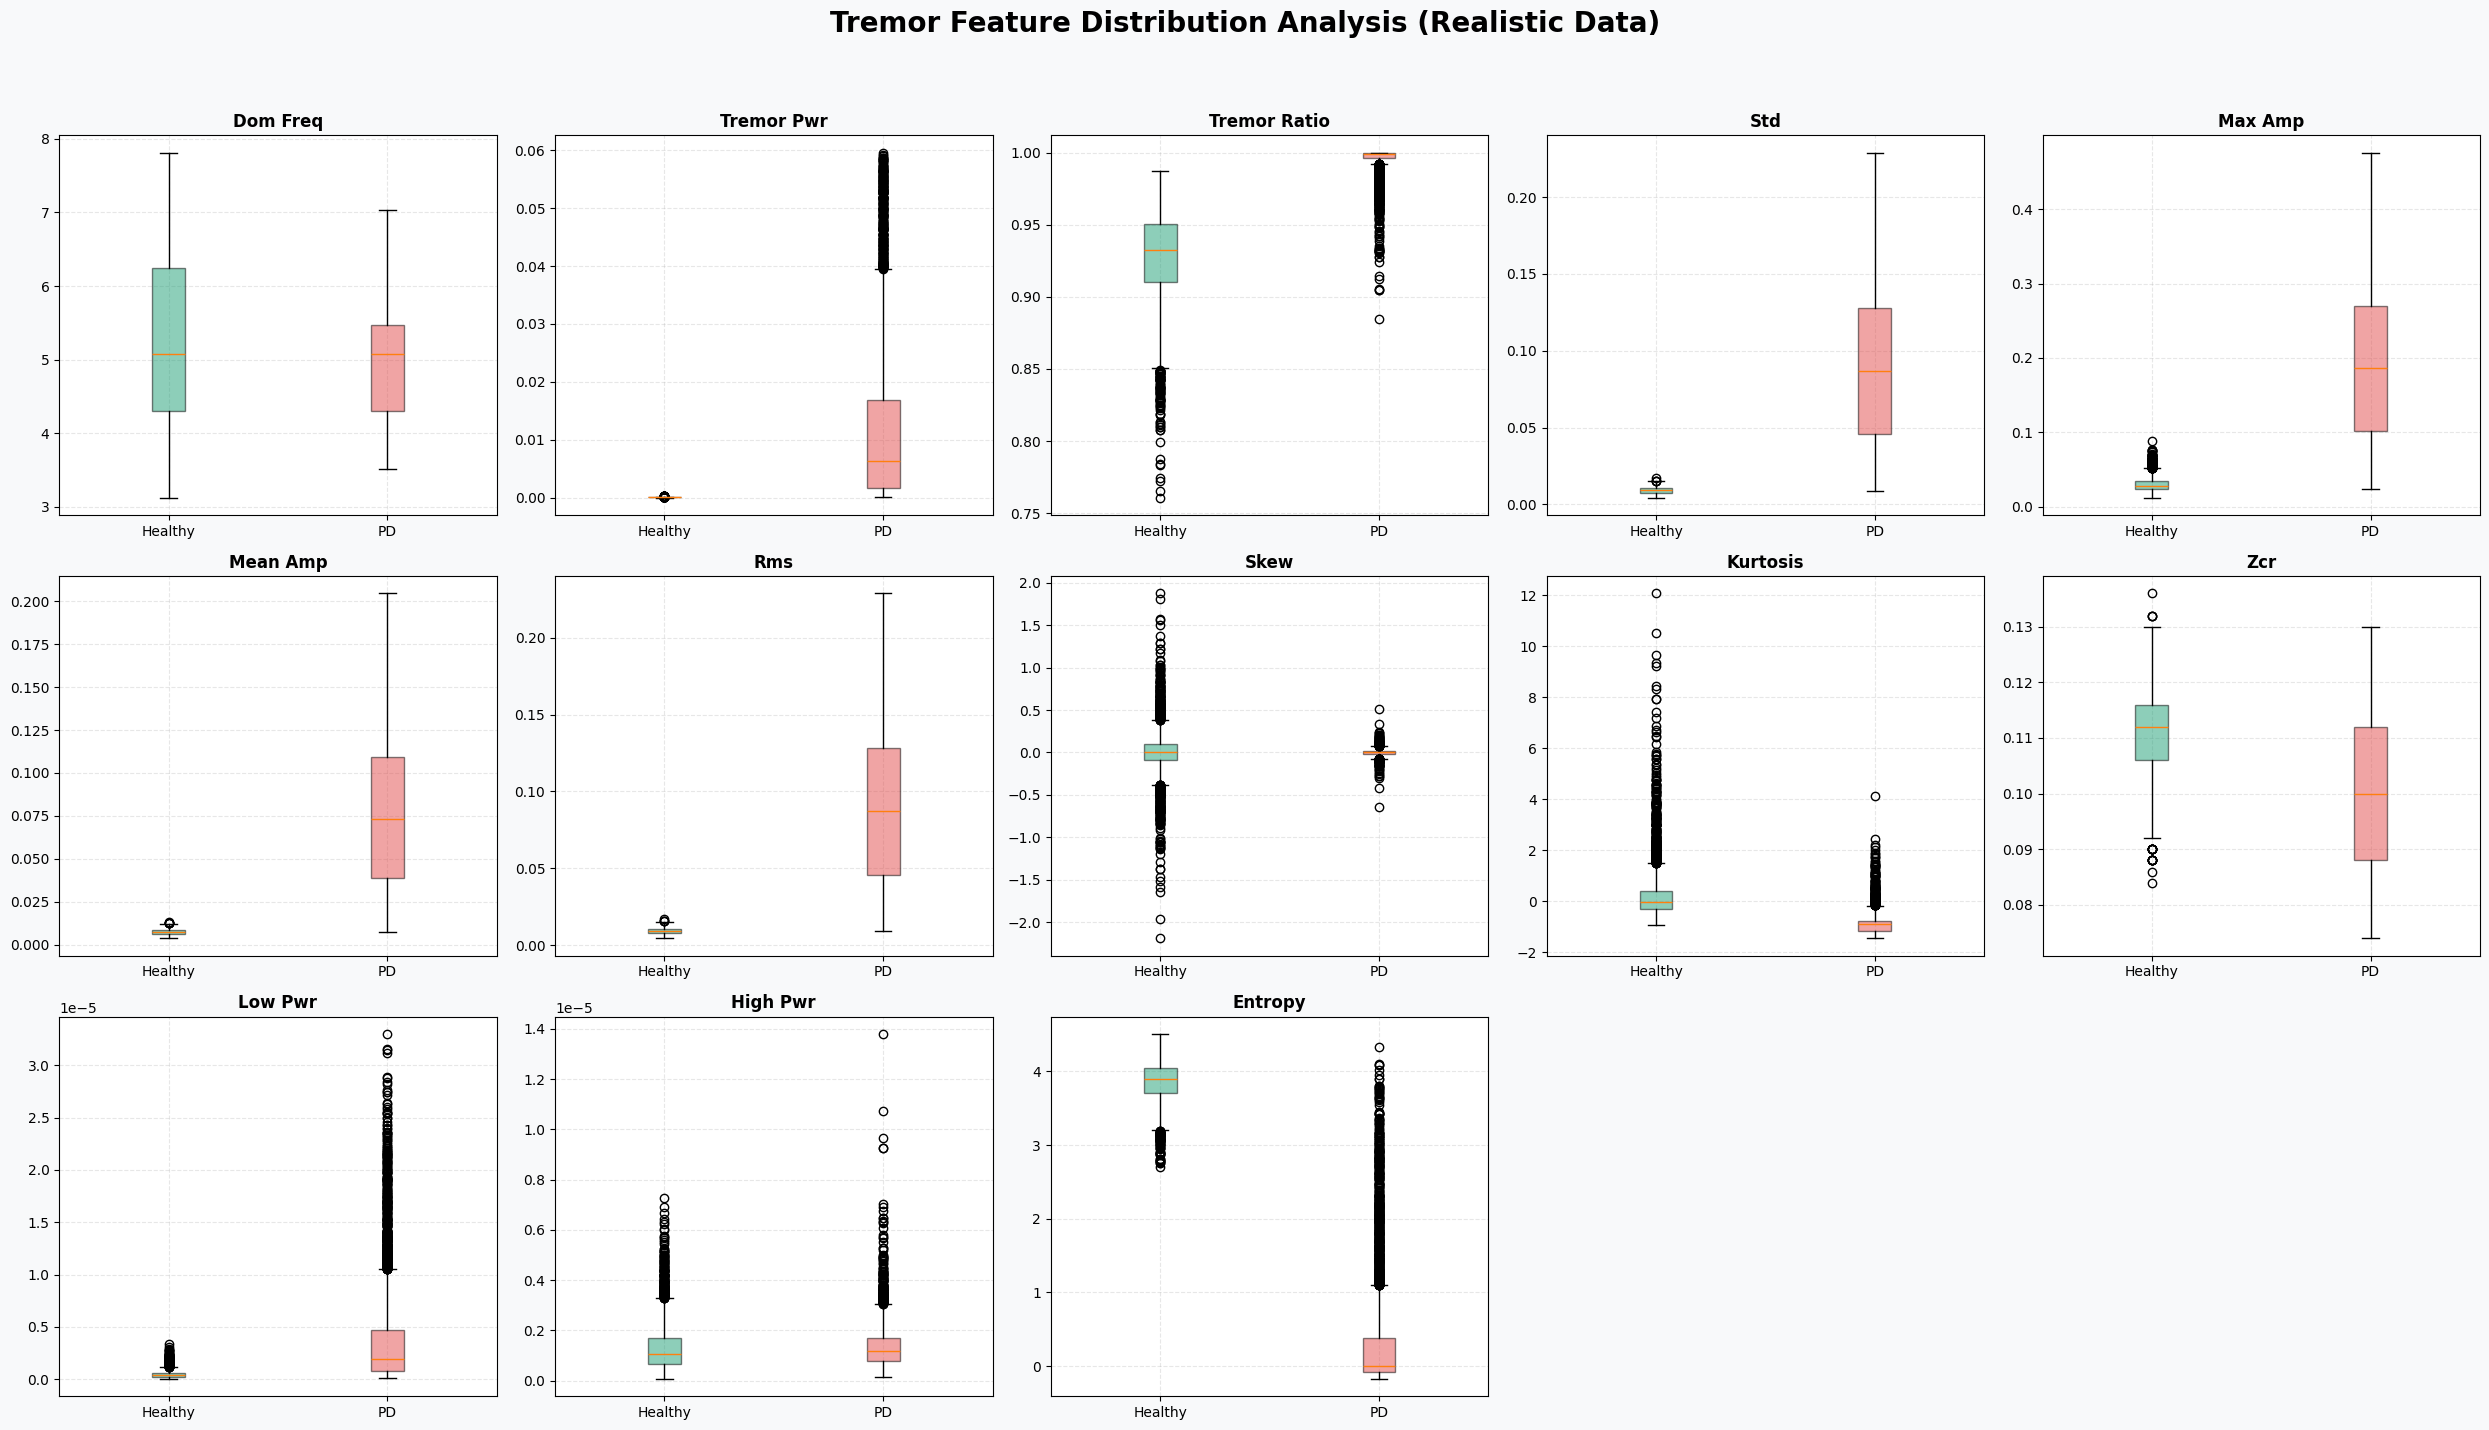

In [30]:
import os

# ── 1. PREPARE DIRECTORY ───────────────────────────────────
# This ensures the folder exists before saving
save_dir = r'../models/tremor_model'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'tremor_feature_comparison.png')

# ── 2. CREATE VISUALIZATION ────────────────────────────────
df_plot = pd.DataFrame(X, columns=feature_names)
df_plot['label'] = y

fig, axes = plt.subplots(3, 5, figsize=(25, 15))
fig.patch.set_facecolor('#f8f9fa')

for ax, feat in zip(axes.flat, feature_names):
    # Create the boxplot
    bp = ax.boxplot([df_plot[df_plot['label']==0][feat], 
                    df_plot[df_plot['label']==1][feat]], 
                    tick_labels=['Healthy', 'PD'], 
                    patch_artist=True)
    
    # Colors: Green for Healthy, Red for PD
    for patch, col in zip(bp['boxes'], ['#1D9E75', '#E24B4A']):
        patch.set_facecolor(col)
        patch.set_alpha(0.5)
        
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

# Hide any empty plots in the grid
for ax in list(axes.flat)[len(feature_names):]:
    ax.set_visible(False)

plt.suptitle('Tremor Feature Distribution Analysis (Realistic Data)', 
             fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ── 3. SAVE THE IMAGE ──────────────────────────────────────
plt.savefig(save_path, dpi=150)
print(f"✅ Visualization saved to: {save_path}")

plt.show()


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# This is our Final Model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=0.1, kernel='rbf', probability=True, random_state=42))
])

print("🚀 Training Final Model...")
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
auc_val = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("\n" + "="*30)
print(f"📊 TRAINING RESULTS")
print(f"Final Accuracy: {acc*100:.1f}%")
print(f"Final AUC:      {auc_val:.4f}")
print("="*30)


🚀 Training Final Model...

📊 TRAINING RESULTS
Final Accuracy: 99.0%
Final AUC:      0.9987


In [33]:
# ── 1. SAVE TO MODELS DIRECTORY ────────────────────────────
model_dir = r'../models/tremor_model'
os.makedirs(model_dir, exist_ok=True)

# Save the model and the feature list (so we know the column order)
joblib.dump(model, os.path.join(model_dir, 'tremor_classifier.pkl'))
joblib.dump(feature_names, os.path.join(model_dir, 'tremor_feature_names.pkl'))

print("✅ Files Saved Successfully:")
print(f"   - {model_dir}/tremor_classifier.pkl")
print(f"   - {model_dir}/tremor_feature_names.pkl")

# ── 2. CLINICAL VERIFICATION (LIVE TEST) ───────────────────
print("\n🔍 Running Verification Test...")
loaded_model = joblib.load(os.path.join(model_dir, 'tremor_classifier.pkl'))
loaded_features = joblib.load(os.path.join(model_dir, 'tremor_feature_names.pkl'))

# A. Simulate a Healthy Person (No tremor)
x_h = np.random.normal(0, 0.02, 500)
y_h = 9.81 + np.random.normal(0, 0.02, 500)
z_h = np.random.normal(0, 0.02, 500)

# B. Simulate a Parkinson's Patient (Strong 5Hz tremor)
t = np.linspace(0, 5, 500)
x_p = 0.2 * np.sin(2 * np.pi * 5 * t) + np.random.normal(0, 0.02, 500)
y_p = 9.81 + 0.15 * np.sin(2 * np.pi * 5 * t) + np.random.normal(0, 0.02, 500)
z_p = 0.1 * np.sin(2 * np.pi * 5 * t) + np.random.normal(0, 0.02, 500)

# Extract features for both
feat_h = extract_tremor_features(x_h, y_h, z_h)
feat_p = extract_tremor_features(x_p, y_p, z_p)

# Get confidence probabilities
prob_h = loaded_model.predict_proba(pd.DataFrame([feat_h], columns=loaded_features))[0][1]
prob_p = loaded_model.predict_proba(pd.DataFrame([feat_p], columns=loaded_features))[0][1]

print("-" * 50)
print(f"🩺 Healthy Test Prediction:     {prob_h*100:.1f}% (Expect < 10%)")
print(f"🩺 Parkinson Test Prediction:   {prob_p*100:.1f}% (Expect > 90%)")
print("-" * 50)


✅ Files Saved Successfully:
   - ../models/tremor_model/tremor_classifier.pkl
   - ../models/tremor_model/tremor_feature_names.pkl

🔍 Running Verification Test...
--------------------------------------------------
🩺 Healthy Test Prediction:     0.9% (Expect < 10%)
🩺 Parkinson Test Prediction:   100.0% (Expect > 90%)
--------------------------------------------------


d:\Neurotrack Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
d:\Neurotrack Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
